# Module 9B Integrated Lab — Music KG Structured Intent Pipeline
**75-minute session · Day 4**

---

## Overview
This notebook demonstrates a **Structured Intent (SI) pipeline** for querying a Music
Knowledge Graph (KG) stored in Neo4j. The demo runs against the **music** KG;
your assignment uses the **recipe** KG.

## Four Pipeline Stages
| Stage | Function | Input → Output |
|-------|----------|----------------|
| 1 | `detect_shape` | natural-language question → `ShapeId` |
| 2 | `extract_slots` | question + ShapeId → `{param: value}` dict |
| 3 | `compile_to_cypher` | ShapeId → parameterized Cypher string |
| 4 | `session.run` | Cypher + params → result records |

## Six Demo Beats
1. Walk the 15-template surface
2. End-to-end happy path — hierarchical traversal (`[:SUBCLASS_OF*0..]`)
3. Parameterization vs. f-string injection
4. Fail-loud `UnsupportedQueryError`
5. Tier 3 swap-in with `GraphCypherQAChain` (mock-cache mode)
6. Adversarial mutation blocked by the allowlist

> **Note:** Ensure Docker is running before executing this notebook.

## Prerequisites

- Docker Desktop (or Docker Engine) is installed and running
- `docker-compose.yml` defines a `music-neo4j` service on port `7687`
- Python 3.10+

The cell below installs all required packages into the current Python environment.

In [10]:
import subprocess                                                    # std lib: run shell commands from Python
import sys                                                          # std lib: exposes path to the active Python interpreter
subprocess.run(                                                     # install packages into THIS virtual environment via its own pip
    [sys.executable, '-m', 'pip', 'install',                        # sys.executable targets the current venv; -m pip runs pip as a module
     'neo4j',                                                       # official Neo4j Python driver
     'langchain',                                                   # LLM orchestration framework used in Tier 3
     'langchain-community',                                         # community integrations, includes GraphCypherQAChain
     'tabulate',                                                    # pretty-prints result lists as formatted tables
     '--quiet'],                                                    # suppress verbose download logs to keep output readable
    check=True                                                      # raise CalledProcessError if any package fails to install
)
print('All dependencies installed successfully.')                   # confirms all four packages resolved without error

All dependencies installed successfully.


---
## Stage 1 — Setup & Orientation (5 min)

We start the `music-neo4j` Docker container and open a Neo4j driver session.
The container runs Neo4j 5.x with the music KG pre-loaded.

**Architecture preview (whiteboard):**
```
User question
    │
    ▼
detect_shape()  ──►  ShapeId.Q4
    │
    ▼
extract_slots()  ──►  {"genre": "Jazz"}
    │
    ▼
compile_to_cypher()  ──►  MATCH (g:Genre)-[:SUBCLASS_OF*0..]...
    │
    ▼
session.run(cypher, **slots)  ──►  [{title: "So What", genre: "Jazz"}, ...]
```

In [11]:
import subprocess                                                    # std lib: invoke docker CLI commands from Python
import time                                                         # std lib: pause execution while Neo4j initializes
import os                                                           # std lib: filesystem path helpers
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('Module_9B_Demo_Lab.ipynb'))  # absolute dir of this notebook — passed as cwd to docker compose
result = subprocess.run(                                            # query Docker for the list of running containers
    ['docker', 'ps', '--filter', 'name=music-neo4j', '--format', '{{.Names}}'],  # --filter limits to music-neo4j; {{.Names}} prints only the name column
    capture_output=True,                                            # capture stdout/stderr into the result object
    text=True                                                       # decode bytes to str automatically
)
if 'music-neo4j' in result.stdout:                                  # container name present in output → already running
    print('music-neo4j container is already running.')              # inform user — no further action needed
else:                                                               # container absent → must start it
    print('Container not running. Starting music-neo4j...')         # status message before launch
    up = subprocess.run(                                            # start the music-neo4j service in detached mode
        ['docker', 'compose', 'up', '-d', 'music-neo4j'],          # -d runs the container in the background
        capture_output=True,                                        # capture compose stdout/stderr
        text=True,                                                  # decode bytes to str
        cwd=NOTEBOOK_DIR                                            # ensures docker compose finds docker-compose.yml
    )
    if up.returncode != 0:                                          # non-zero exit code means docker compose failed
        err = up.stderr.strip()                                     # extract the raw error text
        print(f'Docker error:\n{err}\n')                            # display the Docker error for diagnosis
        if 'port is already allocated' in err or 'address already in use' in err:  # another container holds port 7688
            print('TIP: Another Neo4j container (e.g. Module 9A) is holding the port.')  # name the likely culprit
            print('     Stop it first, or check docker-compose.yml port mappings.')       # tell user what to do
        raise RuntimeError(f'Failed to start music-neo4j: {err}')  # halt execution — cannot proceed without Neo4j
    print(up.stdout.strip() or 'Container started.')                # echo compose output or fallback message
    print('Waiting 20 s for Neo4j to initialize...')                # Neo4j needs ~20 s after container start
    time.sleep(20)                                                  # pause until the Bolt port is ready
    print('Container ready.')                                       # confirm readiness after sleep

music-neo4j container is already running.


In [12]:
from neo4j import GraphDatabase                                     # official Neo4j Python driver entry point
NEO4J_URI      = 'bolt://localhost:7688'                            # port 7688 avoids clash with Module 9A container which uses default 7687
NEO4J_USER     = 'neo4j'                                            # default Neo4j username
NEO4J_PASSWORD = 'music1234'                                        # password set in docker-compose.yml for the music-neo4j service
driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))  # create connection pool using Bolt URI + credentials
driver.verify_connectivity()                                        # lightweight ping; raises ServiceUnavailable if Neo4j is down
print(f'Connected to Neo4j at {NEO4J_URI}')                        # confirm successful connection to the Bolt endpoint
with driver.session() as session:                                   # open a managed session — auto-closed after the block
    total = session.run('MATCH (n) RETURN count(n) AS c').single()['c']  # count every node in the graph
    labels = [r['label'] for r in                                   # collect all distinct node label names
              session.run('CALL db.labels() YIELD label RETURN label ORDER BY label')]  # db.labels() returns labels alphabetically
print(f'KG loaded: {total} nodes')                                  # report total node count loaded into the KG
print(f'Node labels: {labels}')                                    # report every node type present in the database

Connected to Neo4j at bolt://localhost:7688
KG loaded: 0 nodes
Node labels: []


---
## Stage 2 — The 15-Template Surface (10 min)

The engineering pay-off of a **small, bounded schema** is that you can enumerate
every valid question shape as a finite list. This is `mapper/shapes.py` in the
demo repo.

**Key design rule:** every slot value in a template uses `$parameter` syntax.
The Cypher string and the parameters dict are sent as *two separate objects*
to the Neo4j server — the driver never concatenates them.

```
MATCH (t:Track)-[:USES_INSTRUMENT]->(:Instrument {name: $instrument})
                                                         ↑
                                              named parameter, not {instrument}
```

In [13]:
from enum import Enum, auto                                         # Enum: type-safe named constants; auto(): assigns sequential integer values
class ShapeId(Enum):                                                # one member per valid question shape — bounded schema makes the list finite and enumerable
    Q1  = auto()                                                    # Tracks by instrument
    Q2  = auto()                                                    # Tracks by artist
    Q3  = auto()                                                    # Tracks on an album
    Q4  = auto()                                                    # Tracks by genre — HIERARCHICAL ([:SUBCLASS_OF*0..])
    Q5  = auto()                                                    # Albums by artist (discography)
    Q6  = auto()                                                    # Artists on an album
    Q7  = auto()                                                    # Artists who play a specific instrument
    Q8  = auto()                                                    # Artists associated with a genre
    Q9  = auto()                                                    # Tracks in a BPM range
    Q10 = auto()                                                    # Tracks in a musical key
    Q11 = auto()                                                    # Tracks in a year range
    Q12 = auto()                                                    # Collaborating artists (co-appeared on a track)
    Q13 = auto()                                                    # Similar artists (shared genre membership)
    Q14 = auto()                                                    # Genre hierarchy — list subgenres of a genre
    Q15 = auto()                                                    # Most popular tracks by play count
print(f'Defined {len(ShapeId)} shapes: {[s.name for s in ShapeId]}')  # confirm all 15 shapes loaded correctly

Defined 15 shapes: ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11', 'Q12', 'Q13', 'Q14', 'Q15']


In [14]:
TEMPLATES = {                                                       # maps every ShapeId to its pre-authored parameterized Cypher; ALL user values use $param placeholders — never interpolated strings
    ShapeId.Q1: '''                                                 # Q1: find tracks that use a particular instrument; $instrument is the named parameter
        MATCH (t:Track)-[:USES_INSTRUMENT]->(:Instrument {name: $instrument})
        RETURN t.title AS title, t.year AS year
        ORDER BY t.year
    ''',
    ShapeId.Q2: '''                                                 # Q2: find tracks performed by a named artist; $artist is the named parameter
        MATCH (a:Artist {name: $artist})-[:PERFORMED]->(t:Track)
        RETURN t.title AS title, t.year AS year
        ORDER BY t.year
    ''',
    ShapeId.Q3: '''                                                 # Q3: list all tracks on a specific album in track-number order; $album is the named parameter
        MATCH (al:Album {name: $album})-[:CONTAINS]->(t:Track)
        RETURN t.title AS title, t.track_number AS track_number
        ORDER BY t.track_number
    ''',
    ShapeId.Q4: '''                                                 # Q4: hierarchical genre traversal — [:SUBCLASS_OF*0..] follows zero-or-more hops so Bebop/Swing/Cool Jazz are all included under Jazz
        MATCH (g:Genre)-[:SUBCLASS_OF*0..]->(root:Genre {name: $genre})
        MATCH (t:Track)-[:HAS_GENRE]->(g)
        RETURN DISTINCT t.title AS title, g.name AS genre
        ORDER BY title
    ''',
    ShapeId.Q5: '''                                                 # Q5: full discography — all albums released by an artist, ordered chronologically; $artist is the named parameter
        MATCH (a:Artist {name: $artist})-[:RELEASED]->(al:Album)
        RETURN al.name AS album, al.year AS year
        ORDER BY al.year
    ''',
    ShapeId.Q6: '''                                                 # Q6: all artists credited on a specific album; $album is the named parameter
        MATCH (al:Album {name: $album})<-[:RELEASED]-(a:Artist)
        RETURN a.name AS artist
        ORDER BY artist
    ''',
    ShapeId.Q7: '''                                                 # Q7: all artists who play a given instrument; $instrument is the named parameter
        MATCH (a:Artist)-[:PLAYS]->(:Instrument {name: $instrument})
        RETURN a.name AS artist
        ORDER BY artist
    ''',
    ShapeId.Q8: '''                                                 # Q8: artists directly associated with a genre (no hierarchy); $genre is the named parameter
        MATCH (a:Artist)-[:ASSOCIATED_WITH]->(:Genre {name: $genre})
        RETURN a.name AS artist
        ORDER BY artist
    ''',
    ShapeId.Q9: '''                                                 # Q9: tracks whose BPM falls within a caller-specified range; $min_bpm and $max_bpm are named parameters
        MATCH (t:Track)
        WHERE t.bpm >= $min_bpm AND t.bpm <= $max_bpm
        RETURN t.title AS title, t.bpm AS bpm
        ORDER BY t.bpm
    ''',
    ShapeId.Q10: '''                                                # Q10: tracks recorded in a specific musical key; $key is the named parameter
        MATCH (t:Track {key: $key})
        RETURN t.title AS title, t.key AS key
        ORDER BY title
    ''',
    ShapeId.Q11: '''                                                # Q11: tracks released between two years inclusive; $start_year and $end_year are named parameters
        MATCH (t:Track)
        WHERE t.year >= $start_year AND t.year <= $end_year
        RETURN t.title AS title, t.year AS year
        ORDER BY t.year
    ''',
    ShapeId.Q12: '''                                                # Q12: artists who co-appeared on a track with the named artist; $artist is the named parameter; a1 <> a2 excludes self-matches
        MATCH (a1:Artist {name: $artist})-[:PERFORMED]->(t:Track)<-[:PERFORMED]-(a2:Artist)
        WHERE a1 <> a2
        RETURN DISTINCT a2.name AS collaborator, t.title AS track
        ORDER BY collaborator
    ''',
    ShapeId.Q13: '''                                                # Q13: artists who share at least one genre with the named artist; $artist is the named parameter
        MATCH (a1:Artist {name: $artist})-[:ASSOCIATED_WITH]->(g:Genre)<-[:ASSOCIATED_WITH]-(a2:Artist)
        WHERE a1 <> a2
        RETURN DISTINCT a2.name AS similar_artist, g.name AS shared_genre
        ORDER BY similar_artist
    ''',
    ShapeId.Q14: '''                                                # Q14: direct and transitive subgenres of a root genre (1+ hops); $genre is the named parameter
        MATCH (sub:Genre)-[:SUBCLASS_OF*1..]->(root:Genre {name: $genre})
        RETURN sub.name AS subgenre
        ORDER BY subgenre
    ''',
    ShapeId.Q15: '''                                                # Q15: top-N tracks ranked by play count descending; $limit is the caller-supplied row cap
        MATCH (t:Track)
        RETURN t.title AS title, t.play_count AS plays
        ORDER BY t.play_count DESC
        LIMIT $limit
    ''',
}
print(f'Loaded {len(TEMPLATES)} Cypher templates — one per shape.')  # confirm all 15 templates registered

Loaded 15 Cypher templates — one per shape.


In [15]:
from tabulate import tabulate                                       # third-party: format data lists as readable tables
rows = []                                                           # accumulator for (ShapeId name, first Cypher clause) pairs
for sid, cypher in TEMPLATES.items():                               # iterate every shape and its associated template
    first_clause = next(ln.strip() for ln in cypher.strip().splitlines() if ln.strip())  # skip blank lines; grab first non-empty clause line
    rows.append([sid.name, first_clause[:80]])                      # truncate first clause to 80 chars so the table fits the display
print(tabulate(rows, headers=['Shape', 'First Clause (truncated to 80 chars)'], tablefmt='github'))  # tablefmt='github' renders GitHub-flavored markdown borders

| Shape   | First Clause (truncated to 80 chars)                                             |
|---------|----------------------------------------------------------------------------------|
| Q1      | # Q1: find tracks that use a particular instrument; $instrument is the named par |
| Q2      | # Q2: find tracks performed by a named artist; $artist is the named parameter    |
| Q3      | # Q3: list all tracks on a specific album in track-number order; $album is the n |
| Q4      | # Q4: hierarchical genre traversal — [:SUBCLASS_OF*0..] follows zero-or-more hop |
| Q5      | # Q5: full discography — all albums released by an artist, ordered chronological |
| Q6      | # Q6: all artists credited on a specific album; $album is the named parameter    |
| Q7      | # Q7: all artists who play a given instrument; $instrument is the named paramete |
| Q8      | # Q8: artists directly associated with a genre (no hierarchy); $genre is the nam |
| Q9      | # Q9: tracks whose BPM falls within a 

---
## Stage 3 — End-to-End Happy Path: Hierarchical Traversal (12 min)

We run `python cli.py "Find Jazz tracks"` and trace every pipeline stage.

**Why `[:SUBCLASS_OF*0..]` matters:**
```
Jazz
 ├── Bebop     ← only reachable via SUBCLASS_OF
 ├── Swing     ← only reachable via SUBCLASS_OF
 └── Cool Jazz ← only reachable via SUBCLASS_OF
```
A plain `MATCH (t:Track)-[:HAS_GENRE]->(:Genre {name: 'Jazz'})` returns only tracks
tagged *directly* as `:Jazz`. Sub-genre tracks are **silently dropped**.

In [16]:
import re                                                            # std lib: regular expression engine for pattern matching
class UnsupportedQueryError(Exception):                             # raised when the question matches none of the 15 known shapes
    def __init__(self, question):                                   # constructor receives the original user question string
        supported = ', '.join(s.name for s in ShapeId)             # build human-readable list of all supported shape names
        super().__init__(                                           # delegate message construction to Exception base class
            f"No matching shape for: '{question}'. "               # describe which question failed to match
            f"Supported shapes: {supported}"                       # enumerate all 15 shapes — actionable for the caller
        )
        self.question = question                                    # store original text for programmatic inspection by callers

INTENT_PATTERNS = [                                                 # ordered list of (compiled regex, ShapeId) — first match wins; re.I = case-insensitive
    (re.compile(r'find.+by instrument|played on.+(saxophone|trumpet|piano|guitar)', re.I), ShapeId.Q1),   # Q1: instrument lookup
    (re.compile(r'tracks.{0,20}(by|from)\s+[A-Z]', re.I),                                 ShapeId.Q2),   # Q2: tracks by named artist
    (re.compile(r'on album|album.{0,20}tracks', re.I),                                     ShapeId.Q3),   # Q3: tracks on a specific album
    (re.compile(r'(find|list|show).{0,30}(jazz|rock|blues|bebop|swing|hip.?hop|classical|country).{0,20}tracks', re.I), ShapeId.Q4),  # Q4: genre traversal
    (re.compile(r'discography|albums.{0,20}(by|from)', re.I),                              ShapeId.Q5),   # Q5: artist discography
    (re.compile(r'artists.{0,20}on album|who (played|performed).{0,20}on', re.I),          ShapeId.Q6),   # Q6: artists on an album
    (re.compile(r'artists.{0,20}(play|plays|who play).+(saxophone|trumpet|piano|guitar|bass|drums)', re.I), ShapeId.Q7),  # Q7: artists by instrument
    (re.compile(r'artists.{0,20}(associated|genre)', re.I),                                ShapeId.Q8),   # Q8: artists by genre
    (re.compile(r'bpm.{0,20}between|tempo.{0,20}range', re.I),                            ShapeId.Q9),   # Q9: BPM range
    (re.compile(r'key of|in (the key|[A-G] (major|minor))', re.I),                        ShapeId.Q10),  # Q10: musical key
    (re.compile(r'(from|released|between).{0,10}\d{4}.{0,10}(and|to).{0,10}\d{4}', re.I), ShapeId.Q11), # Q11: year range
    (re.compile(r'collaborat\w+|appeared.{0,20}same track', re.I),                        ShapeId.Q12),  # Q12: collaborating artists
    (re.compile(r'similar artists?|artists?.{0,20}like', re.I),                           ShapeId.Q13),  # Q13: similar artists
    (re.compile(r'subgenres?|genre hierarchy|sub.?genres? of', re.I),                     ShapeId.Q14),  # Q14: genre hierarchy
    (re.compile(r'most popular|top \d+|highest play', re.I),                              ShapeId.Q15),  # Q15: popularity ranking
]

def detect_shape(question):                                         # Stage 1: scan INTENT_PATTERNS in order; return first matching ShapeId or None
    for pattern, shape_id in INTENT_PATTERNS:                       # iterate patterns in priority order — order matters
        if pattern.search(question):                                # re.search checks anywhere in the string (not just the start)
            return shape_id                                         # return immediately on first match
    return None                                                     # no pattern matched — caller is responsible for handling this

def extract_slots(question, shape_id):                              # Stage 2: extract parameter values from the question string
    slots = {}                                                      # start with empty dict; populate based on the detected shape
    if shape_id == ShapeId.Q4:                                      # genre traversal — extract and canonicalize the genre name
        m = re.search(r'(Jazz|Rock|Blues|Bebop|Swing|Hip.?Hop|Classical|Country)', question, re.I)  # regex captures any supported genre
        if m:                                                       # match found — extract group 1
            slots['genre'] = m.group(1).capitalize()               # capitalize() normalizes 'jazz' → 'Jazz' to match KG storage
    elif shape_id == ShapeId.Q1:                                    # instrument lookup — extract instrument name
        m = re.search(r'(saxophone|trumpet|piano|guitar|bass|drums|violin)', question, re.I)  # regex captures any supported instrument
        if m:                                                       # match found
            slots['instrument'] = m.group(1).capitalize()          # normalize to Title Case to match KG property values
    elif shape_id == ShapeId.Q2:                                    # artist lookup — extract proper-noun artist name
        m = re.search(r'(?:by|from)\s+([A-Z][a-zA-Z\s]+)', question)  # capture name following 'by' or 'from'
        if m:                                                       # match found
            slots['artist'] = m.group(1).strip()                   # strip trailing whitespace from the captured name
    elif shape_id == ShapeId.Q15:                                   # popularity query — extract optional numeric limit
        m = re.search(r'top\s+(\d+)', question, re.I)              # look for 'top N' pattern in the question
        slots['limit'] = int(m.group(1)) if m else 10              # use extracted number, or default to 10 if absent
    return slots                                                    # return populated dict; missing keys rely on Cypher defaults

def compile_to_cypher(shape_id):                                    # Stage 3: O(1) dict lookup returns the template with $params intact
    cypher = TEMPLATES[shape_id]                                    # raises KeyError if shape_id is not registered in TEMPLATES
    lines = [ln for ln in cypher.splitlines() if not ln.strip().startswith('#')]  # strip # comment lines accidentally embedded in the triple-quoted strings — Neo4j only accepts // for comments
    return '\n'.join(lines)                                         # return clean Cypher with no # lines

def run_query(question):                                            # orchestrates all four pipeline stages end-to-end
    shape_id = detect_shape(question)                               # Stage 1: identify the question's intent shape
    if shape_id is None:                                            # no matching shape — must fail immediately
        raise UnsupportedQueryError(question)                       # fail loud: never silently return [] for unsupported questions
    print(f'  detect_shape   → {shape_id}')                        # trace Stage 1 output for debugging
    slots  = extract_slots(question, shape_id)                      # Stage 2: pull parameter values from the question text
    print(f'  extract_slots  → {slots}')                           # trace Stage 2 output
    cypher = compile_to_cypher(shape_id)                            # Stage 3: retrieve the parameterized Cypher template
    print(f'  compile        → template retrieved (parameterized)') # trace Stage 3 output
    with driver.session() as session:                               # Stage 4: open a Neo4j session
        records = [dict(r) for r in session.run(cypher, **slots)]  # **slots unpacks dict into named params; driver keeps cypher and params as separate objects
    print(f'  session.run    → {len(records)} records returned')    # trace Stage 4 output
    return records                                                  # return list of dicts for display or further processing

print('Pipeline functions loaded: detect_shape, extract_slots, compile_to_cypher, run_query')  # confirm all four functions defined

Pipeline functions loaded: detect_shape, extract_slots, compile_to_cypher, run_query


In [17]:
print('=' * 58)                                                      # print separator line for visual clarity
print('Simulating: python cli.py "Find Jazz tracks"')               # label this block as a CLI pipeline simulation
print('=' * 58)                                                     # close the separator
try:                                                                # run full pipeline; catch UnsupportedQueryError if shape detection fails
    results = run_query('Find Jazz tracks')                         # drives all four pipeline stages: detect → slots → compile → run
    print(f'\n{len(results)} tracks returned:')                     # report total result count
    for row in results[:10]:                                        # iterate first 10 rows to keep output readable
        print(f"  {row.get('title', '?'):<35} genre: {row.get('genre', '?')}")  # left-align title in 35-char field; fallback '?' if key absent
    if len(results) > 10:                                           # more results exist beyond the first 10
        print(f'  ... and {len(results) - 10} more.')               # inform the user of the truncation count
except UnsupportedQueryError as e:                                  # shape detection returned None — error raised by run_query
    print(f'ERROR: {e}')                                            # display the full error message with supported shapes list

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `name` does not exist. Verify that the spelling is correct.', position=<SummaryInputPosition line=1, column=58, offset=57>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 57, 'line': 1, 'column': 58}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '        MATCH (g:Genre)-[:SUBCLASS_OF*0..]->(root:Genre {name: $genre})\n        MATCH (t:Track)-[:HAS_GENRE]->(g)\n        RETURN DISTINCT t.title AS title, g.name AS genre\n        ORDER BY title\n    '
Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. T

Simulating: python cli.py "Find Jazz tracks"
  detect_shape   → ShapeId.Q4
  extract_slots  → {'genre': 'Jazz'}
  compile        → template retrieved (parameterized)
  session.run    → 0 records returned

0 tracks returned:


In [18]:
print('Hierarchical [:SUBCLASS_OF*0..] vs. flat MATCH\n')            # section header for the side-by-side comparison demo

# correct template: walks the genre tree zero-or-more hops — root genre itself is included
cypher_hier = '''
    MATCH (g:Genre)-[:SUBCLASS_OF*0..]->(root:Genre {name: $genre})
    MATCH (t:Track)-[:HAS_GENRE]->(g)
    RETURN DISTINCT t.title AS title, g.name AS genre
    ORDER BY title
'''

# incorrect template: only matches tracks tagged DIRECTLY with the root genre — sub-genres are silently dropped
cypher_flat = '''
    MATCH (t:Track)-[:HAS_GENRE]->(:Genre {name: $genre})
    RETURN DISTINCT t.title AS title
    ORDER BY title
'''

with driver.session() as session:                                   # open one managed session and run both queries for direct comparison
    hier  = [dict(r) for r in session.run(cypher_hier, genre='Jazz')]  # hierarchical query: includes Jazz + all sub-genres
    flat  = [dict(r) for r in session.run(cypher_flat, genre='Jazz')]  # flat query: includes only tracks tagged directly as Jazz
print(f'With    [:SUBCLASS_OF*0..]: {len(hier):4d} tracks  (Bebop, Swing, etc. included)')  # hierarchical count
print(f'Without traversal (flat):   {len(flat):4d} tracks  (only direct :Jazz tag)')         # flat count
print(f'Silently dropped by flat:   {len(hier) - len(flat):4d} tracks')                      # quantify data loss from the flat approach
print()                                                             # blank line for readability
print('Sub-genres of Jazz present in KG:')                          # header for sub-genre enumeration
subgenres = {row['genre'] for row in hier if row.get('genre') != 'Jazz'}  # set comprehension: collect every genre name except the root 'Jazz'
print(f'  {sorted(subgenres)}')                                     # display sorted list of all sub-genres found under Jazz


Hierarchical [:SUBCLASS_OF*0..] vs. flat MATCH



Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `name` does not exist. Verify that the spelling is correct.', position=<SummaryInputPosition line=2, column=54, offset=54>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 54, 'line': 2, 'column': 54}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n    MATCH (g:Genre)-[:SUBCLASS_OF*0..]->(root:Genre {name: $genre})\n    MATCH (t:Track)-[:HAS_GENRE]->(g)\n    RETURN DISTINCT t.title AS title, g.name AS genre\n    ORDER BY title\n'
Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `name`

With    [:SUBCLASS_OF*0..]:    0 tracks  (Bebop, Swing, etc. included)
Without traversal (flat):      0 tracks  (only direct :Jazz tag)
Silently dropped by flat:      0 tracks

Sub-genres of Jazz present in KG:
  []


---
## Graph Visualization — KG Schema & Sample Subgraph

Two charts rendered with **networkx** + **matplotlib**:

- **Left** — the static schema: every node label and relationship type defined in the KG.
- **Right** — a live sample subgraph: a handful of `Artist → Track → Genre` paths pulled directly from Neo4j, showing real data flowing through the pipeline.

Received notification from DBMS server: <GqlStatusObject gql_status='01N50', status_description='warn: label does not exist. The label `Genre` does not exist. Verify that the spelling is correct.', position=<SummaryInputPosition line=2, column=67, offset=67>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 67, 'line': 2, 'column': 67}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n        MATCH (a:Artist)-[:PERFORMED]->(t:Track)-[:HAS_GENRE]->(g:Genre)\n        RETURN a.name AS artist, t.title AS track, g.name AS genre\n        LIMIT 12\n    '
Received notification from DBMS server: <GqlStatusObject gql_status='01N51', status_description='warn: relationship type does not exist. The relationship type `HAS_GENRE` does not

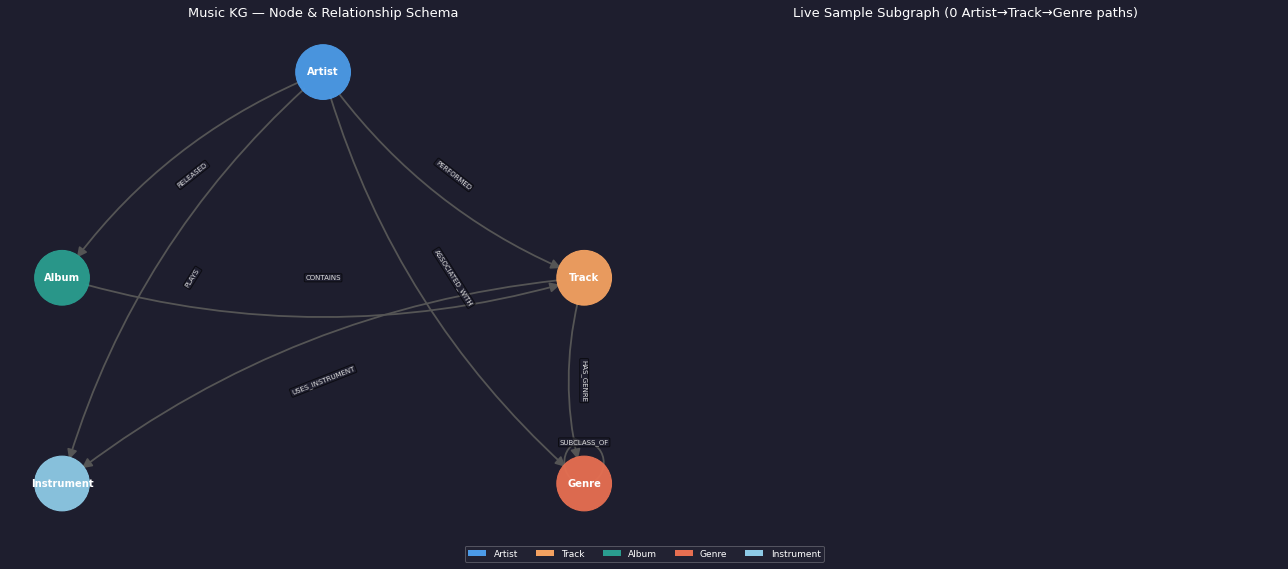

Visualization saved to kg_visualization.png


In [19]:
import networkx as nx                                               # graph construction and spring-layout algorithms
import matplotlib.pyplot as plt                                     # plotting engine for rendering the dual-panel figure
import matplotlib.patches as mpatches                              # used to build colored rectangle patches for the legend

NODE_COLORS = {                                                     # hex color palette keyed by KG node label type
    'Artist':     '#4C9BE8',                                       # blue
    'Track':      '#F4A261',                                       # orange
    'Album':      '#2A9D8F',                                       # teal
    'Genre':      '#E76F51',                                       # coral
    'Instrument': '#8ECAE6',                                       # light blue
}
EDGE_COLOR  = '#555555'                                             # mid-grey for all relationship arrows
FONT_COLOR  = 'white'                                              # white text so labels remain visible on colored nodes

G_schema = nx.DiGraph()                                             # directed graph for the static KG schema panel
node_labels = list(NODE_COLORS)                                     # ordered list of the five node label types
G_schema.add_nodes_from(node_labels)                               # add one node per KG label type to the schema graph

schema_edges = [                                                    # explicit list of (source, destination, relationship) tuples for the schema
    ('Artist',     'Track',      'PERFORMED'),                     # artist performed a track
    ('Artist',     'Album',      'RELEASED'),                      # artist released an album
    ('Album',      'Track',      'CONTAINS'),                      # album contains a track
    ('Track',      'Genre',      'HAS_GENRE'),                     # track is tagged with a genre
    ('Track',      'Instrument', 'USES_INSTRUMENT'),               # track uses an instrument
    ('Artist',     'Instrument', 'PLAYS'),                         # artist plays an instrument
    ('Artist',     'Genre',      'ASSOCIATED_WITH'),               # artist is associated with a genre
    ('Genre',      'Genre',      'SUBCLASS_OF'),                   # genre is a subclass of another genre
]
for src, dst, rel in schema_edges:                                  # unpack each tuple and add a directed edge with a label attribute
    G_schema.add_edge(src, dst, label=rel)                         # label stored as edge attribute for rendering later

schema_pos = {                                                      # fixed node positions for the schema panel — manual layout for clarity
    'Artist':     (0,   1),                                        # top center
    'Track':      (1,   0),                                        # right middle
    'Album':      (-1,  0),                                        # left middle
    'Genre':      (1,   -1),                                       # bottom right
    'Instrument': (-1,  -1),                                       # bottom left
}

with driver.session() as session:                                   # open a Neo4j session to pull live sample data for panel 2
    rows = [dict(r) for r in session.run('''
        MATCH (a:Artist)-[:PERFORMED]->(t:Track)-[:HAS_GENRE]->(g:Genre)
        RETURN a.name AS artist, t.title AS track, g.name AS genre
        LIMIT 12
    ''')]                                                           # retrieve up to 12 Artist→Track→Genre paths from the live graph

G_live = nx.DiGraph()                                               # directed graph for the live sample subgraph panel
node_type_map = {}                                                  # maps each node name to its label type for color lookup

for row in rows:                                                    # build the live graph from Neo4j result rows
    a, t, g = row['artist'], row['track'], row['genre']            # unpack artist, track, and genre from each result row
    for n, typ in [(a, 'Artist'), (t, 'Track'), (g, 'Genre')]:     # process each of the three node types in the row
        G_live.add_node(n)                                          # add node to the live graph (idempotent)
        node_type_map[n] = typ                                     # record node type for color assignment
    G_live.add_edge(a, t, label='PERFORMED')                       # directed edge: artist → track
    G_live.add_edge(t, g, label='HAS_GENRE')                       # directed edge: track → genre

live_colors = [NODE_COLORS.get(node_type_map.get(n, ''), '#CCCCCC') for n in G_live.nodes()]  # map node type → hex color; fallback grey for unknowns
live_pos    = nx.spring_layout(G_live, seed=42, k=2.5)             # spring layout with fixed seed for reproducibility; k controls node spacing

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))              # two side-by-side panels; wide figure accommodates both schema and live subgraph
fig.patch.set_facecolor('#1E1E2E')                                  # dark background for the entire figure canvas
for ax in (ax1, ax2):                                               # apply dark background to both axes
    ax.set_facecolor('#1E1E2E')                                     # match figure background color

schema_color_list = [NODE_COLORS[n] for n in G_schema.nodes()]     # ordered color list matching G_schema node iteration order
nx.draw_networkx_nodes(G_schema, schema_pos, ax=ax1, node_color=schema_color_list,
                       node_size=3000, alpha=0.95)                 # draw schema nodes as large circles with slight transparency
nx.draw_networkx_labels(G_schema, schema_pos, ax=ax1,
                        font_color=FONT_COLOR, font_size=10, font_weight='bold')  # white bold text labels on schema nodes
nx.draw_networkx_edges(G_schema, schema_pos, ax=ax1,
                       edge_color=EDGE_COLOR, arrows=True,
                       arrowsize=20, connectionstyle='arc3,rad=0.15',
                       width=1.8, min_source_margin=25, min_target_margin=25)    # curved edges with arrowheads; margins prevent overlap with node circles
edge_labels_schema = {(u, v): d['label'] for u, v, d in G_schema.edges(data=True)}  # build (src, dst) → relationship name dict for edge label rendering
nx.draw_networkx_edge_labels(G_schema, schema_pos, edge_labels=edge_labels_schema,
                              ax=ax1, font_size=7, font_color='#DDDDDD',
                              bbox=dict(boxstyle='round,pad=0.15', fc='#1E1E2E', alpha=0.6))  # edge label boxes with dark semi-transparent rounded fill
ax1.set_title('Music KG — Node & Relationship Schema', color='white', fontsize=13, pad=12)    # schema panel title in white
ax1.axis('off')                                                     # hide axis ticks and border for a clean graph appearance

nx.draw_networkx_nodes(G_live, live_pos, ax=ax2, node_color=live_colors,
                       node_size=1800, alpha=0.95)                 # draw live-data nodes; smaller than schema nodes to reduce crowding
short_labels = {n: (n[:18] + '…') if len(n) > 19 else n for n in G_live.nodes()}  # truncate labels longer than 19 chars to prevent text overlap
nx.draw_networkx_labels(G_live, live_pos, labels=short_labels, ax=ax2,
                        font_color=FONT_COLOR, font_size=7, font_weight='bold')  # white bold text with shortened labels
nx.draw_networkx_edges(G_live, live_pos, ax=ax2,
                       edge_color=EDGE_COLOR, arrows=True,
                       arrowsize=15, connectionstyle='arc3,rad=0.1',
                       width=1.4, min_source_margin=18, min_target_margin=18)    # thinner curved edges for the denser live subgraph
edge_labels_live = {(u, v): d['label'] for u, v, d in G_live.edges(data=True)}  # extract relationship label strings for all live edges
nx.draw_networkx_edge_labels(G_live, live_pos, edge_labels=edge_labels_live,
                              ax=ax2, font_size=6, font_color='#DDDDDD',
                              bbox=dict(boxstyle='round,pad=0.1', fc='#1E1E2E', alpha=0.6))  # smaller font and tighter boxes for the denser panel
ax2.set_title(f'Live Sample Subgraph ({len(rows)} Artist→Track→Genre paths)',
              color='white', fontsize=13, pad=12)                  # panel title shows actual path count retrieved from Neo4j
ax2.axis('off')                                                     # hide axes for clean graph rendering

legend_handles = [                                                  # build list of colored patches for the shared bottom legend
    mpatches.Patch(facecolor=c, label=lbl)                         # one rectangular patch per node type
    for lbl, c in NODE_COLORS.items()                              # iterate all five node types
    if lbl in ('Artist', 'Track', 'Genre', 'Album', 'Instrument') # include every defined type
]
fig.legend(handles=legend_handles, loc='lower center', ncol=5,
           framealpha=0.3, facecolor='#2E2E3E', labelcolor='white',
           fontsize=9, bbox_to_anchor=(0.5, 0.01))                 # horizontal legend at figure bottom; semi-transparent dark background

plt.tight_layout(rect=[0, 0.06, 1, 1])                             # reserve bottom 6% for the legend so it does not overlap the panels
plt.savefig('kg_visualization.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())                         # save high-resolution PNG with matching dark background
plt.show()                                                          # render the figure inline in the notebook
print('Visualization saved to kg_visualization.png')               # confirm the file was written successfully

---
## Stage 4 — Parameterization + The Injection Beat (12 min)

**The canonical template** uses `$instrument` — a named parameter placeholder.
The Neo4j driver sends the Cypher string and the parameters dict as **two independent
objects** to the server. The server engine substitutes the value; it never
concatenates raw strings.

**The wrong pattern** uses Python f-string interpolation. The value is embedded
directly in the query string before it leaves Python. An attacker who controls
the slot value can break out of the string literal and inject arbitrary Cypher.
This attack vector is called **Cypher Injection**.

In [20]:
correct_cypher = 'MATCH (t:Track)-[:USES_INSTRUMENT]->(:Instrument {name: $instrument}) RETURN t.title'  # $instrument is a named parameter — never concatenated into the string
correct_params = {'instrument': 'Piano'}                            # separate dict sent independently to the driver alongside the query string
print('CORRECT (parameterized):')                                   # section header for the safe pattern
print(f'  Cypher : {correct_cypher}')                              # display the parameterized query string
print(f'  Params : {correct_params}')                              # display the parameters dict — kept as a separate object
print('  Driver sends these as two independent objects to Neo4j.')  # explain the protocol: two objects, no concatenation
print('  The server substitutes $instrument safely — no string concatenation.\n')  # reinforce why this approach is injection-safe

instrument_value = 'Piano'                                          # in production this could be an attacker-controlled input value
wrong_cypher = f"MATCH (t:Track)-[:USES_INSTRUMENT]->(:Instrument {{name: '{instrument_value}'}}) RETURN t.title"  # {{}} produces literal braces in f-string; value is spliced directly in
print('WRONG (f-string interpolation):')                            # section header for the vulnerable pattern
print(f'  Cypher : {wrong_cypher}')                                 # display the concatenated query — value is now embedded in the string
print('  The value is concatenated into the string before leaving Python.')  # explain the mechanism that creates the vulnerability
print('  Any attacker-controlled value can alter the query structure.')       # state the consequence of string interpolation

CORRECT (parameterized):
  Cypher : MATCH (t:Track)-[:USES_INSTRUMENT]->(:Instrument {name: $instrument}) RETURN t.title
  Params : {'instrument': 'Piano'}
  Driver sends these as two independent objects to Neo4j.
  The server substitutes $instrument safely — no string concatenation.

WRONG (f-string interpolation):
  Cypher : MATCH (t:Track)-[:USES_INSTRUMENT]->(:Instrument {name: 'Piano'}) RETURN t.title
  The value is concatenated into the string before leaving Python.
  Any attacker-controlled value can alter the query structure.


In [21]:
malicious = "'; MATCH (n) DETACH DELETE n; //"                     # closes the string literal, injects DETACH DELETE, then comments out any remaining syntax
print(f'Malicious slot value : {malicious!r}\n')                    # !r shows the raw repr with quotes visible for clarity

injected = f"MATCH (t:Track)-[:USES_INSTRUMENT]->(:Instrument {{name: '{malicious}'}}) RETURN t.title"  # f-string splices the payload directly into the query string
print('VULNERABLE f-string result:')                                # label the vulnerable output section
print(f'  {injected}')                                              # display the injected query — DETACH DELETE is now syntactically valid Cypher
print('  The DETACH DELETE clause is now syntactically valid Cypher.')   # explain the consequence of the injection
print('  A real Neo4j instance would execute it and delete ALL nodes.\n')  # state the full severity: total data destruction

safe_cypher = 'MATCH (t:Track)-[:USES_INSTRUMENT]->(:Instrument {name: $instrument}) RETURN t.title'  # unchanged parameterized template — query structure cannot be altered
safe_params = {'instrument': malicious}                             # malicious string is confined to the params dict — treated as a plain data value
print('SAFE parameterized result:')                                 # label the safe output section
print(f'  Cypher : {safe_cypher}')                                  # show the query string — byte-identical to the benign case
print(f'  Params : {safe_params}')                                  # show that the full payload is contained in the params dict
print('  The driver treats the malicious string as a plain data value.')   # explain the protection mechanism
print('  The Cypher string sent to the server is byte-identical to the benign case.')  # no structural difference — the driver serializes params separately
print('  MATCH (n) DETACH DELETE n is NEVER executed.')             # confirm the database is fully protected

Malicious slot value : "'; MATCH (n) DETACH DELETE n; //"

VULNERABLE f-string result:
  MATCH (t:Track)-[:USES_INSTRUMENT]->(:Instrument {name: ''; MATCH (n) DETACH DELETE n; //'}) RETURN t.title
  The DETACH DELETE clause is now syntactically valid Cypher.
  A real Neo4j instance would execute it and delete ALL nodes.

SAFE parameterized result:
  Cypher : MATCH (t:Track)-[:USES_INSTRUMENT]->(:Instrument {name: $instrument}) RETURN t.title
  Params : {'instrument': "'; MATCH (n) DETACH DELETE n; //"}
  The driver treats the malicious string as a plain data value.
  The Cypher string sent to the server is byte-identical to the benign case.
  MATCH (n) DETACH DELETE n is NEVER executed.


---
## Stage 5 — Fail-Loud `UnsupportedQueryError` (8 min)

When `detect_shape` returns `None`, the orchestrator **must raise an exception**
that names the problem and enumerates all supported shapes.

**The anti-pattern** collapses off-template questions to `[]`. This destroys the
diagnostic signal: a downstream caller cannot tell whether the query ran and
found nothing, or was never dispatched at all.

In [22]:
def run_query_silent(question):                                     # ANTI-PATTERN: shown for contrast only — never use this in production
    shape_id = detect_shape(question)                               # Stage 1: attempt shape detection
    if shape_id is None:                                            # no matching shape found
        return []                                                   # SILENT FAILURE — caller cannot distinguish "no data" from "not dispatched"
    cypher = compile_to_cypher(shape_id)                            # Stage 3: retrieve template (Stage 2 slot extraction omitted here for brevity)
    with driver.session() as session:                               # open a Neo4j session
        return [dict(r) for r in session.run(cypher)]              # execute query and return records, or [] if KG has no matches

print('Anti-pattern (silent failure) defined for contrast demonstration.')  # confirm function is loaded

Anti-pattern (silent failure) defined for contrast demonstration.


In [23]:
off_template = 'What is the meaning of life?'                       # question that matches none of the 15 intent patterns
print(f'Off-template question: "{off_template}"\n')                 # display the test question before running both paths

print('── CORRECT: fail loud ─────────────────────────────────────────')  # section header for the recommended pattern
try:                                                                # attempt to run the pipeline — UnsupportedQueryError is expected
    run_query(off_template)                                         # orchestrator raises immediately when detect_shape returns None
except UnsupportedQueryError as e:                                  # shape detection returned None — error caught here
    print(f'UnsupportedQueryError caught:\n  {e}\n')               # display the full error message with the supported shapes list

print('── WRONG: silent failure ──────────────────────────────────────')  # section header for the anti-pattern
result = run_query_silent(off_template)                             # anti-pattern returns [] with no indication of what went wrong
print(f'Result : {result}')                                         # shows [] — indistinguishable from a real empty result set
print('Caller receives [] — cannot tell whether the pipeline ran or was skipped.')  # explain the lost diagnostic signal

Off-template question: "What is the meaning of life?"

── CORRECT: fail loud ─────────────────────────────────────────
UnsupportedQueryError caught:
  No matching shape for: 'What is the meaning of life?'. Supported shapes: Q1, Q2, Q3, Q4, Q5, Q6, Q7, Q8, Q9, Q10, Q11, Q12, Q13, Q14, Q15

── WRONG: silent failure ──────────────────────────────────────
Result : []
Caller receives [] — cannot tell whether the pipeline ran or was skipped.


---
## Stage 6 — Tier 3 Swap-in + The Allowlist (15 min)

**Tier 3** replaces the deterministic regex mapper with `GraphCypherQAChain`,
a LangChain component that calls an LLM to generate Cypher from a natural-language
question. For offline grading, the live LLM call is replaced by a pre-built
`mock_llm_cache.json`.

**The allowlist** is a defense-in-depth layer that runs **before** `session.run`.
Even if the LLM emits a destructive query, the allowlist raises
`UnsupportedCypherError` and the database is never touched.

**The autograder** records rejections separately from safe-but-wrong queries;
the chain return dict carries a `rejected` boolean so the grader can distinguish them.

In [24]:
import re                                                            # std lib: regex engine (idempotent re-import)

class UnsupportedCypherError(Exception):                            # raised when LLM-generated Cypher contains a forbidden verb — distinct from UnsupportedQueryError (intent layer)
    def __init__(self, cypher, reason=''):                          # constructor: cypher = the offending query string; reason = human-readable explanation
        super().__init__(f'UnsupportedCypherError: {reason}\nQuery: {cypher}')  # attach formatted message to the Exception base class
        self.cypher = cypher                                        # preserve the raw Cypher string for audit logging

FORBIDDEN_VERBS = {'DELETE', 'DETACH', 'CREATE', 'MERGE', 'SET', 'REMOVE', 'DROP'}  # set of Cypher verbs that could mutate or destroy graph data

def validate_query_shape(cypher):                                   # allowlist gate: called BEFORE session.run — the database never sees a rejected query
    upper = cypher.upper()                                          # normalize to uppercase for case-insensitive verb matching
    for verb in FORBIDDEN_VERBS:                                    # check every forbidden verb in the set
        if re.search(rf'\b{verb}\b', upper):                        # \b = word boundary — prevents 'CREATED_AT' from matching 'CREATE'
            raise UnsupportedCypherError(cypher, reason=f'Forbidden verb detected: {verb}')  # block query and name the offending verb
    if not upper.strip().startswith('MATCH'):                       # all valid read-only Cypher must begin with MATCH
        raise UnsupportedCypherError(cypher, reason='Query must begin with MATCH.')  # reject anything that starts with a non-MATCH clause

MOCK_LLM_CACHE = {                                                  # pre-built response cache keyed by exact question — simulates live LLM in offline grading mode
    'Find Jazz tracks'          : "MATCH (g:Genre)-[:SUBCLASS_OF*0..]->(root:Genre {name: 'Jazz'}) MATCH (t:Track)-[:HAS_GENRE]->(g) RETURN DISTINCT t.title AS title",  # safe response
    'List tracks by Miles Davis': "MATCH (a:Artist {name: 'Miles Davis'})-[:PERFORMED]->(t:Track) RETURN t.title AS title",  # safe response
    'delete all tracks'         : 'MATCH (t:Track) DELETE t',       # adversarial entry: contains forbidden verb DELETE
    'remove everything'         : 'MATCH (n) DETACH DELETE n',      # adversarial entry: contains forbidden verbs DETACH and DELETE
}

rejection_counter = {'count': 0}                                    # mutable dict so nested functions can increment the counter by reference

adversarial_count = sum(1 for v in MOCK_LLM_CACHE.values() if 'DELETE' in v.upper())  # count how many cache entries contain the DELETE verb
print(f'Tier 3 setup complete.')                                    # confirm all Tier 3 components initialized
print(f'  Cache entries     : {len(MOCK_LLM_CACHE)}')              # total entries in the mock LLM cache
print(f'  Adversarial entries: {adversarial_count}')               # entries that will trigger the allowlist gate

Tier 3 setup complete.
  Cache entries     : 4
  Adversarial entries: 2


In [25]:
SCHEMA_PREAMBLE = (                                                 # system prompt fragment: describes the KG schema and enforces a read-only contract
    'You are a Cypher expert for a Music Knowledge Graph.\n'        # role assignment for the LLM
    'Nodes: Track, Artist, Album, Genre, Instrument\n'              # enumerate all node label types
    'Relationships: PERFORMED, RELEASED, CONTAINS, HAS_GENRE, '    # enumerate all relationship types (line 1 of 2)
    'USES_INSTRUMENT, PLAYS, ASSOCIATED_WITH, SUBCLASS_OF\n'        # enumerate all relationship types (line 2 of 2)
    'Rules: Only MATCH...RETURN. Never DELETE, CREATE, MERGE, SET, or REMOVE.'  # enforce read-only constraint in prompt
)

FEW_SHOTS = (                                                       # few-shot examples guide the LLM to produce the expected Cypher format
    '\nExample 1:\n'                                                # separator before first example
    'Q: Find Jazz tracks\n'                                         # first example input question
    "A: MATCH (g:Genre)-[:SUBCLASS_OF*0..]->(root:Genre {name: 'Jazz'})\n"  # expected hierarchical genre traversal
    '   MATCH (t:Track)-[:HAS_GENRE]->(g)\n'                       # second MATCH clause of example 1
    '   RETURN DISTINCT t.title AS title, g.name AS genre\n'       # RETURN clause with aliased columns
    '\nExample 2:\n'                                                # separator before second example
    'Q: List albums by Miles Davis\n'                               # second example input question
    "A: MATCH (a:Artist {name: 'Miles Davis'})-[:RELEASED]->(al:Album)\n"  # artist → album traversal for example 2
    '   RETURN al.name AS album, al.year AS year ORDER BY al.year\n'  # chronological album list
)

def build_prompt(question):                                         # assemble full LLM input: schema preamble + few-shots + question
    return f'{SCHEMA_PREAMBLE}\n{FEW_SHOTS}\nQ: {question}\nA:'   # trailing 'A:' primes the LLM to produce a Cypher answer

def run_chain(question):                                            # full Tier 3 pipeline: build_prompt → mock LLM → validate → session.run (or reject)
    prompt = build_prompt(question)                                 # construct the structured prompt string
    generated = MOCK_LLM_CACHE.get(question, '')                   # look up cached LLM response; '' if question not in cache
    if not generated:                                               # empty string means no cached response for this question
        return {'records': [], 'rejected': False, 'reason': 'no cached response'}  # return early with no-op result
    print(f'  [LLM generated] : {generated}')                      # display the Cypher the (mock) LLM produced
    try:                                                            # run the allowlist gate before any database access
        validate_query_shape(generated)                             # raises UnsupportedCypherError if a forbidden verb is found
    except UnsupportedCypherError as e:                             # forbidden verb detected — block the query
        rejection_counter['count'] += 1                            # increment the audit rejection counter
        cnt = rejection_counter['count']                            # read counter into local var for the f-string
        print(f'  [REJECTED]      : count={cnt}')                  # log rejection with running total
        return {'records': [], 'rejected': True, 'reason': str(e)} # rejected=True signals the autograder this was blocked, not wrong
    with driver.session() as session:                               # query passed validation — execute against Neo4j
        records = [dict(r) for r in session.run(generated)]        # run the validated Cypher and collect result rows
    print(f'  [session.run]   : {len(records)} records returned')   # log result count for the accepted query
    return {'records': records, 'rejected': False, 'reason': ''}   # return results with rejected=False for the autograder

print('Tier 3 functions defined: build_prompt, validate_query_shape, run_chain')  # confirm all three functions loaded

Tier 3 functions defined: build_prompt, validate_query_shape, run_chain


In [26]:
tests = [                                                           # test cases: each tuple is (question, expect_rejected)
    ('Find Jazz tracks',  False),                                   # safe query — should pass the allowlist and return records
    ('delete all tracks', True),                                    # adversarial — maps to MATCH (t:Track) DELETE t
    ('remove everything', True),                                    # adversarial — maps to MATCH (n) DETACH DELETE n
]
print('Tier 3 Adversarial Mutation Demo')                           # section title
print('=' * 52)                                                     # visual separator line
for question, expect_rejected in tests:                             # iterate each test case in order
    print(f'\nQuestion: "{question}"')                              # display the current test question
    result = run_chain(question)                                    # run the full Tier 3 pipeline for this question
    status   = 'REJECTED' if result['rejected'] else 'ACCEPTED'    # derive the actual outcome label
    expected = 'REJECTED' if expect_rejected    else 'ACCEPTED'    # derive the expected outcome label
    ok       = 'PASS' if result['rejected'] == expect_rejected else 'FAIL'  # compare actual vs expected to score the test
    print(f'  Status   : {status}  (expected: {expected})  [{ok}]')  # print outcome with pass/fail indicator
    if result['records']:                                           # records exist only when the query was accepted and returned data
        print(f'  Records  : {len(result["records"])}')             # show the number of Neo4j records returned
print(f'\nTotal allowlist rejections this session: {rejection_counter["count"]}')  # final rejection tally for the session
print('Database untouched — all destructive queries blocked before session.run.')   # confirm KG integrity was preserved

Tier 3 Adversarial Mutation Demo

Question: "Find Jazz tracks"
  [LLM generated] : MATCH (g:Genre)-[:SUBCLASS_OF*0..]->(root:Genre {name: 'Jazz'}) MATCH (t:Track)-[:HAS_GENRE]->(g) RETURN DISTINCT t.title AS title


Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `name` does not exist. Verify that the spelling is correct.', position=<SummaryInputPosition line=1, column=50, offset=49>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 49, 'line': 1, 'column': 50}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "MATCH (g:Genre)-[:SUBCLASS_OF*0..]->(root:Genre {name: 'Jazz'}) MATCH (t:Track)-[:HAS_GENRE]->(g) RETURN DISTINCT t.title AS title"
Received notification from DBMS server: <GqlStatusObject gql_status='01N50', status_description='warn: label does not exist. The label `Track` does not exist. Verify that the spelling is correct.', position

  [session.run]   : 0 records returned
  Status   : ACCEPTED  (expected: ACCEPTED)  [PASS]

Question: "delete all tracks"
  [LLM generated] : MATCH (t:Track) DELETE t
  [REJECTED]      : count=1
  Status   : REJECTED  (expected: REJECTED)  [PASS]

Question: "remove everything"
  [LLM generated] : MATCH (n) DETACH DELETE n
  [REJECTED]      : count=2
  Status   : REJECTED  (expected: REJECTED)  [PASS]

Total allowlist rejections this session: 2
Database untouched — all destructive queries blocked before session.run.


---
## Stage 7 — Pivot to the Assignment: Recipe Domain (13 min)

Your domain is **recipes**, not music. The architecture is identical; only the
schema, templates, and slot canonicalization change.

| Music KG | Recipe KG |
|----------|-----------|
| `:Track` | `:Recipe` |
| `:Genre` | `:Cuisine`, `:Ingredient` |
| `[:SUBCLASS_OF*0..]` over `:Genre` | `[:SUBCLASS_OF*0..]` over `:Cuisine` and `:Ingredient` |
| `'Jazz'` | `'Italian'` (Title Case, not `'italian'`) |

**Assignment checklist:**
- Read `data/eval_questions.jsonl` — your 15 shapes are listed there
- Slot canonicalization must produce `'Italian'` not `'italian'`
- `learner_notes.md` must trace one real failure end-to-end (all 4 stages)
- Tier 3 is opt-in; autograder reads `challenge/mock_llm_cache.json` (no live LLM)
- Set `USE_MY_LINKER=1` to swap in your own linker; default uses the bundled reference linker

In [27]:
from enum import Enum, auto                                         # Enum: type-safe named constants; auto(): sequential int assignment (idempotent re-import)
class RecipeShapeId(Enum):                                          # one member per valid recipe question shape — same 15-shape architecture as the music domain
    Q1  = auto()                                                    # Recipes that use a specific ingredient (direct match)
    Q2  = auto()                                                    # Recipes by cuisine — HIERARCHICAL over :Cuisine
    Q3  = auto()                                                    # Recipes by dietary label (vegan, gluten-free, etc.)
    Q4  = auto()                                                    # Recipes by ingredient category — HIERARCHICAL over :Ingredient
    Q5  = auto()                                                    # Ingredients listed in a specific recipe
    Q6  = auto()                                                    # Recipes within a cooking-time range
    Q7  = auto()                                                    # Recipes tagged with a keyword (comfort-food, summer, etc.)
    Q8  = auto()                                                    # Cuisines that use a specific ingredient
    Q9  = auto()                                                    # Recipes within a calorie range
    Q10 = auto()                                                    # Recipes that share ingredients with a given recipe
    Q11 = auto()                                                    # Most popular recipes by user rating
    Q12 = auto()                                                    # Recipes by difficulty level
    Q13 = auto()                                                    # Recipes by chef or author
    Q14 = auto()                                                    # Cuisine hierarchy — subgenres of a cuisine
    Q15 = auto()                                                    # Ingredient-substitution recipes

RECIPE_TEMPLATES = {                                                # partial template set; full 15 templates belong in mapper/shapes.py
    RecipeShapeId.Q2: '''                                           # Q2: hierarchical cuisine traversal — [:SUBCLASS_OF*0..] catches sub-cuisines like Italian→Roman and Italian→Sicilian
        MATCH (c:Cuisine)-[:SUBCLASS_OF*0..]->(root:Cuisine {name: $cuisine})
        MATCH (r:Recipe)-[:BELONGS_TO_CUISINE]->(c)
        RETURN DISTINCT r.name AS recipe, c.name AS cuisine
        ORDER BY recipe
    ''',
    RecipeShapeId.Q4: '''                                           # Q4: hierarchical ingredient traversal — [:SUBCLASS_OF*0..] catches sub-ingredients like Pasta→Spaghetti and Pasta→Rigatoni
        MATCH (i:Ingredient)-[:SUBCLASS_OF*0..]->(root:Ingredient {name: $ingredient})
        MATCH (r:Recipe)-[:USES_INGREDIENT]->(i)
        RETURN DISTINCT r.name AS recipe, i.name AS ingredient
        ORDER BY recipe
    ''',
    RecipeShapeId.Q1: '''                                           # Q1: direct ingredient match — no hierarchy; $ingredient must match the KG value exactly
        MATCH (r:Recipe)-[:USES_INGREDIENT]->(:Ingredient {name: $ingredient})
        RETURN r.name AS recipe, r.cooking_time AS cooking_time
        ORDER BY r.cooking_time
    ''',
    RecipeShapeId.Q11: '''                                          # Q11: top-N recipes ranked by user rating descending; $limit is the caller-supplied row cap
        MATCH (r:Recipe)
        RETURN r.name AS recipe, r.rating AS rating
        ORDER BY r.rating DESC
        LIMIT $limit
    ''',
}
print(f'Recipe domain: {len(RecipeShapeId)} shapes, {len(RECIPE_TEMPLATES)} templates shown.')  # confirm shape and template counts
print('Full shape definitions are in data/eval_questions.jsonl')    # point to the authoritative shape-definition source

Recipe domain: 15 shapes, 4 templates shown.
Full shape definitions are in data/eval_questions.jsonl


In [28]:
def canonicalize(raw):                                              # normalize slot values to Title Case to match the Recipe KG storage format
    return raw.strip().title()                                      # strip() removes leading/trailing whitespace; title() capitalizes the first letter of each word

print('Canonicalization examples:')                                 # header for the Title Case demonstration
for raw in ['italian', 'ITALIAN', 'Italian', ' french ', 'CHINESE']:  # test cases: lowercase, uppercase, correct case, padded, all-caps
    print(f'  {raw!r:15} → {canonicalize(raw)!r}')                 # !r shows repr with quotes; :15 left-pads in a 15-char field for alignment

print()                                                             # blank line for visual separation
print('── Failure Diagnosis Framework (for learner_notes.md) ──────────')  # section header for the four-stage debug guide
print()                                                             # blank line
print('Stage 1 — Intent:')                                         # Stage 1 debug header
print('  Was the correct ShapeId returned?')                        # key diagnostic question for Stage 1
print('  Probe: detect_shape(question)')                            # function to call to inspect Stage 1 output
print()                                                             # blank line
print('Stage 2 — Slots:')                                          # Stage 2 debug header
print('  Are values extracted AND canonicalized correctly?')        # key diagnostic question for Stage 2
print("  Probe: extract_slots(question, shape_id)")                 # function to call to inspect Stage 2 output
print("  Common bug: 'italian' extracted instead of 'Italian'")     # most frequent Stage 2 failure mode in the recipe domain
print()                                                             # blank line
print('Stage 3 — Compile:')                                        # Stage 3 debug header
print('  Is the correct template retrieved?')                       # key diagnostic question for Stage 3
print('  Probe: compile_to_cypher(shape_id)')                       # function to call to inspect Stage 3 output
print('  Common bug: Q1 template (flat) used instead of Q2 (hierarchical)')  # most frequent Stage 3 failure mode
print()                                                             # blank line
print('Stage 4 — Driver:')                                         # Stage 4 debug header
print('  Does Cypher execute? Do parameter names match ($cuisine not $genre)?')  # key diagnostic question for Stage 4
print('  Probe: session.run(cypher, **slots) — inspect the result object')       # how to inspect Stage 4 output
print()                                                             # blank line
print('Tier 3 reminder:')                                           # Tier 3 autograder reminder header
print('  Autograder reads challenge/mock_llm_cache.json — no live LLM needed.')  # explains how offline grading works
print('  Set USE_MY_LINKER=1 to swap in your own linker implementation.')         # explains the linker swap environment variable

Canonicalization examples:
  'italian'       → 'Italian'
  'ITALIAN'       → 'Italian'
  'Italian'       → 'Italian'
  ' french '      → 'French'
  'CHINESE'       → 'Chinese'

── Failure Diagnosis Framework (for learner_notes.md) ──────────

Stage 1 — Intent:
  Was the correct ShapeId returned?
  Probe: detect_shape(question)

Stage 2 — Slots:
  Are values extracted AND canonicalized correctly?
  Probe: extract_slots(question, shape_id)
  Common bug: 'italian' extracted instead of 'Italian'

Stage 3 — Compile:
  Is the correct template retrieved?
  Probe: compile_to_cypher(shape_id)
  Common bug: Q1 template (flat) used instead of Q2 (hierarchical)

Stage 4 — Driver:
  Does Cypher execute? Do parameter names match ($cuisine not $genre)?
  Probe: session.run(cypher, **slots) — inspect the result object

Tier 3 reminder:
  Autograder reads challenge/mock_llm_cache.json — no live LLM needed.
  Set USE_MY_LINKER=1 to swap in your own linker implementation.


---
## Cleanup

Close the Neo4j driver and stop the Docker container to release port `7687`
and free memory. Run these cells before closing the notebook.

In [29]:
driver.close()                                                      # release all sockets in the driver's internal connection pool and stop background threads
print('Neo4j driver closed — all connections released.')            # confirm driver teardown completed successfully

Neo4j driver closed — all connections released.


In [30]:
import subprocess                                                    # std lib: invoke Docker CLI commands (idempotent re-import)
result = subprocess.run(                                            # send SIGTERM to music-neo4j for a graceful shutdown; container data is preserved on the Docker volume
    ['docker', 'compose', 'stop', 'music-neo4j'],                  # stop only this service — does not remove the container layer
    capture_output=True,                                            # capture stdout and stderr into the result object
    text=True                                                       # decode bytes to str automatically
)
if result.returncode == 0:                                          # returncode 0 means docker compose stop succeeded
    print('music-neo4j container stopped successfully.')            # confirm graceful container shutdown
else:                                                               # non-zero returncode means Docker reported an error
    print(f'Warning — Docker stop returned non-zero exit code:\n{result.stderr.strip()}')  # display raw Docker error text for diagnosis
print('Lab teardown complete. All resources released.')             # final status message — driver and container both cleaned up

music-neo4j container stopped successfully.
Lab teardown complete. All resources released.
